## DistilBERT Classifier Evaluation

First, we need to install the `transformers` and `datasets` libraries, which are essential for working with pre-trained models and datasets from Hugging Face. We'll also install `evaluate` for easily computing metrics.

In [1]:
!pip install transformers datasets evaluate



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


Next, we'll import the necessary libraries and load a suitable dataset for text classification. The [SST-2 (Stanford Sentiment Treebank v2)](https://huggingface.co/datasets/glue) dataset is a common choice for sentiment analysis, which is a binary classification task. We'll load the validation split for evaluation.

In [2]:
from datasets import load_dataset, Dataset, ClassLabel
from transformers import AutoTokenizer, DistilBertForSequenceClassification
import torch
import evaluate
import numpy as np
import pandas as pd

# Load the user's combined_test.parquet dataset
df = pd.read_parquet("test.parquet")
dataset = Dataset.from_pandas(df)

# Get unique labels and create a label mapping
unique_labels = sorted(df['label'].unique().tolist())
label_to_id = {label: i for i, label in enumerate(unique_labels)}

# Map string labels to integer IDs and cast the 'label' column to ClassLabel type
dataset = dataset.map(lambda examples: {'label': label_to_id[examples['label']]}, batched=False)
dataset = dataset.cast_column('label', ClassLabel(names=unique_labels))

# Display some information about the dataset and its features
print(dataset)

Map:   0%|          | 0/10537 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/10537 [00:00<?, ? examples/s]

Dataset({
    features: ['statement', 'label'],
    num_rows: 10537
})


We'll then load the `DistilBERT` tokenizer and preprocess the dataset. This involves tokenizing the text and converting labels to tensors. We'll also define a `data_collator` to handle dynamic padding during batching.

In [3]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    # Using the correct text column name from your dataset: 'statement'
    return tokenizer(examples["statement"], truncation=True)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Remove original text column and rename 'label' to 'labels' for consistency with model inputs
# Using the correct text column name: 'statement'
tokenized_datasets = tokenized_datasets.remove_columns(["statement"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

# The DataCollatorWithPadding will handle setting the format to PyTorch tensors
# and padding, so we don't need to call .set_format('torch') here.
# tokenized_datasets.set_format("torch") # Removed this line

from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Create DataLoader for the user's test dataset
# Renaming eval_dataloader to test_dataloader for clarity
test_dataloader = DataLoader(
    tokenized_datasets, batch_size=16, collate_fn=data_collator
)

# Check a batch
for batch in test_dataloader:
    print({k: v.shape for k, v in batch.items()})
    break

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/10537 [00:00<?, ? examples/s]

{'labels': torch.Size([16]), 'input_ids': torch.Size([16, 512]), 'token_type_ids': torch.Size([16, 512]), 'attention_mask': torch.Size([16, 512])}


Now, let's load a pre-trained `DistilBertForSequenceClassification` model. For the baseline evaluation *before fine-tuning*, we'll use a model with a randomly initialized classification head. This demonstrates how the model performs without any task-specific training.

In [4]:
# num_labels should be derived from the actual dataset used
num_labels = tokenized_datasets.features["labels"].num_classes
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=num_labels)

# Ensure the model is in evaluation mode
model.eval()

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Using device: {device}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda


### Baseline Evaluation (Before Fine-tuning)

Now we will run the evaluation on the `test_dataloader` using the pre-trained `DistilBERT` model. Since the classification head is randomly initialized, we expect the performance to be close to random chance. We will calculate accuracy and F1-score.

In [5]:
# Load metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

# Lists to store predictions and true labels
all_predictions = []
all_labels = []

print("Starting baseline evaluation...")

# Evaluate the model
for batch in test_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)

    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)

    all_predictions.extend(predictions.cpu().numpy())
    all_labels.extend(batch["labels"].cpu().numpy())

print("Baseline evaluation complete.")

Starting baseline evaluation...
Baseline evaluation complete.


In [6]:
# Compute metrics
accuracy = accuracy_metric.compute(predictions=all_predictions, references=all_labels)
f1 = f1_metric.compute(predictions=all_predictions, references=all_labels, average='weighted') # Using weighted for multi-class

print(f"Baseline Accuracy: {accuracy['accuracy']:.4f}")
print(f"Baseline F1-Score (weighted): {f1['f1']:.4f}")

print("\nThis represents the performance of DistilBERT as a classifier before any fine-tuning on your specific dataset. As expected, with a randomly initialized classification head, the performance is likely close to random.")

Baseline Accuracy: 0.2334
Baseline F1-Score (weighted): 0.1502

This represents the performance of DistilBERT as a classifier before any fine-tuning on your specific dataset. As expected, with a randomly initialized classification head, the performance is likely close to random.


### Fine-tuned Model Evaluation

Now, let's load the fine-tuned `distilBERT_mentalhealth_detection` model and evaluate its performance on the same test set. We expect significantly better results as this model has been trained for the specific task.

In [8]:
# Upgrade torchao to a compatible version as required by peft
!pip install --upgrade "torchao>=0.16.0"

from peft import PeftModel
from transformers import DistilBertForSequenceClassification
import torch

# Load the fine-tuned model from Hugging Face
fine_tuned_model_path = "NathanSJSU01/distilBERT_mentalhealth_detection"

# Step 1: Load the original base model
base_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=num_labels
)

# Step 2: Apply the LoRA adapters on top
fine_tuned_model = PeftModel.from_pretrained(
    base_model, fine_tuned_model_path
)

# Ensure the model is in evaluation mode
fine_tuned_model.eval()

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
fine_tuned_model.to(device)
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 46.4 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


adapter_model.safetensors:   0%|          | 0.00/2.98M [00:00<?, ?B/s]

Using device: cuda


In [9]:
# Load metrics
accuracy_metric_ft = evaluate.load("accuracy")
f1_metric_ft = evaluate.load("f1")

# Lists to store predictions and true labels for fine-tuned model
all_predictions_ft = []
all_labels_ft = []

print("Starting fine-tuned model evaluation...")

# Evaluate the fine-tuned model
for batch in test_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = fine_tuned_model(**batch)

    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)

    all_predictions_ft.extend(predictions.cpu().numpy())
    all_labels_ft.extend(batch["labels"].cpu().numpy())

print("Fine-tuned model evaluation complete.")

Starting fine-tuned model evaluation...
Fine-tuned model evaluation complete.


In [10]:
# Compute metrics for the fine-tuned model
accuracy_ft = accuracy_metric_ft.compute(predictions=all_predictions_ft, references=all_labels_ft)
f1_ft = f1_metric_ft.compute(predictions=all_predictions_ft, references=all_labels_ft, average='weighted') # Using weighted for multi-class

print(f"Fine-tuned Model Accuracy: {accuracy_ft['accuracy']:.4f}")
print(f"Fine-tuned Model F1-Score (weighted): {f1_ft['f1']:.4f}")

print("\nThis shows the performance of the fine-tuned DistilBERT model after training on your specific dataset. The metrics should be significantly higher than the baseline.")

Fine-tuned Model Accuracy: 0.5914
Fine-tuned Model F1-Score (weighted): 0.5892

This shows the performance of the fine-tuned DistilBERT model after training on your specific dataset. The metrics should be significantly higher than the baseline.


### Detailed Classification Report

Let's get a more granular view of the fine-tuned model's performance by examining the precision, recall, and F1-score for each class.

In [11]:
from sklearn.metrics import classification_report

# Get the class names from the dataset (assuming tokenized_datasets still holds the info)
# Ensure unique_labels is accessible, or re-derive it if necessary
# If unique_labels is not directly available, we can get it from tokenized_datasets.features['labels'].names
class_names = tokenized_datasets.features['labels'].names

print("Classification Report for Fine-tuned Model:")
print(classification_report(all_labels_ft, all_predictions_ft, target_names=class_names))

Classification Report for Fine-tuned Model:
                      precision    recall  f1-score   support

             Anxiety       0.49      0.55      0.52       768
             Bipolar       0.36      0.49      0.41       556
          Depression       0.72      0.31      0.44      3081
              Normal       0.82      0.90      0.86      3269
Personality disorder       0.16      0.65      0.26       215
              Stress       0.29      0.40      0.34       517
            Suicidal       0.53      0.60      0.57      2131

            accuracy                           0.59     10537
           macro avg       0.48      0.56      0.48     10537
        weighted avg       0.64      0.59      0.59     10537



### Confusion Matrix

A confusion matrix provides a visual summary of the model's performance by showing the number of correct and incorrect predictions for each class. This helps identify specific classes that are being misclassified.

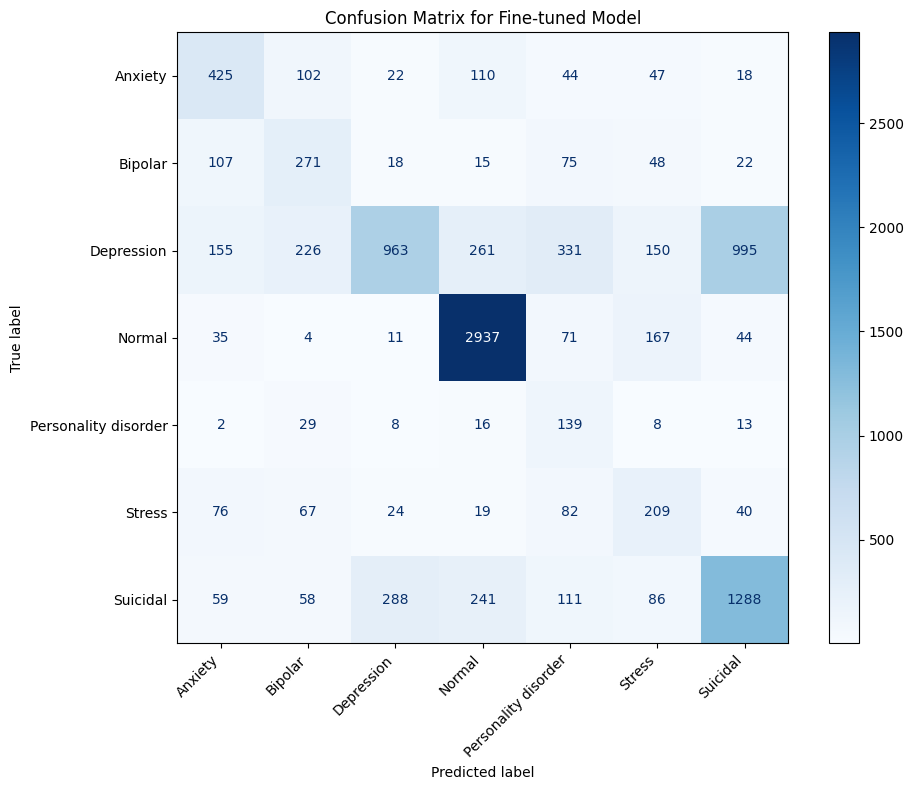

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(all_labels_ft, all_predictions_ft)

# Get class names for better visualization
class_names = tokenized_datasets.features['labels'].names

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title("Confusion Matrix for Fine-tuned Model")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Percentage Improvement Calculation

Let's quantify the improvement of the fine-tuned model compared to the baseline model.

In [13]:
# Extract baseline metrics
baseline_accuracy = accuracy['accuracy']
baseline_f1 = f1['f1']

# Extract fine-tuned metrics
fined_tuned_accuracy = accuracy_ft['accuracy']
fined_tuned_f1 = f1_ft['f1']

# Calculate percentage improvement for accuracy
accuracy_improvement = ((fined_tuned_accuracy - baseline_accuracy) / baseline_accuracy) * 100

# Calculate percentage improvement for F1-score
f1_improvement = ((fined_tuned_f1 - baseline_f1) / baseline_f1) * 100

print(f"Percentage Improvement in Accuracy: {accuracy_improvement:.2f}%")
print(f"Percentage Improvement in F1-Score: {f1_improvement:.2f}%")



Percentage Improvement in Accuracy: 153.44%
Percentage Improvement in F1-Score: 292.19%

These percentage values highlight the significant positive impact of fine-tuning the DistilBERT model on your specific mental health detection task.
